# Simulate Data and compare different models

## Help Functions

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
import seaborn as sns
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

from pycost.analysis.constrained.constrained_model import ConstrainedRegression, ConstrainedRegressionCV

def generate_multicollinear_data(n_samples, n_features, corr_level, true_coefs=None, 
                                 intercept=5.0, noise_level=1.0, seed=None):
    """
    Generate synthetic data with controlled multicollinearity.
    
    Parameters:
    -----------
    n_samples : int
        Number of observations
    n_features : int
        Number of features
    corr_level : float
        Level of correlation between features (0=uncorrelated, 1=perfectly correlated)
    true_coefs : array-like or None
        True coefficient values. If None, random values are generated.
    intercept : float
        True intercept value
    noise_level : float
        Standard deviation of the noise term
    seed : int or None
        Random seed for reproducibility
        
    Returns:
    --------
    X : ndarray
        Design matrix
    y : ndarray
        Response variable
    true_coefs : ndarray
        True coefficient values
    """
    if seed is not None:
        np.random.seed(seed)
        
    # Generate correlation matrix with specified level
    if corr_level > 0:
        # Create a base correlation matrix
        corr_matrix = np.ones((n_features, n_features)) * corr_level
        np.fill_diagonal(corr_matrix, 1.0)
        
        # Generate multivariate normal data
        X = np.random.multivariate_normal(
            mean=np.zeros(n_features),
            cov=corr_matrix,
            size=n_samples
        )
    else:
        # Generate uncorrelated data
        X = np.random.normal(0, 1, size=(n_samples, n_features))
    
    # Generate true coefficients if not provided
    if true_coefs is None:
        true_coefs = np.random.uniform(0, 20, n_features)
        
    # Generate response variable
    y = intercept + X @ true_coefs + np.random.normal(0, noise_level, n_samples)
    
    return X, y, true_coefs


def monte_carlo_simulation(n_samples_list, n_features, corr_levels, 
                           constraints_list, n_simulations=100, seed=42):
    """
    Perform Monte Carlo simulation comparing different regression methods.
    
    Parameters:
    -----------
    n_samples_list : list
        List of sample sizes to test
    n_features : int
        Number of features
    corr_levels : list
        List of multicollinearity levels to test
    constraints_list : list
        List of constraint specifications to test
    n_simulations : int
        Number of simulation runs per configuration
    seed : int
        Random seed for reproducibility
        
    Returns:
    --------
    results_df : DataFrame
        Simulation results
    """
    np.random.seed(seed)
    seeds = np.random.randint(0, 10000, size=n_simulations)
    
    # Initialize results storage
    results = []
    
    # Define methods to compare
    methods = [
        "OLS",
        "Ridge",
        "Lasso",
        "ElasticNet",
        "ConstrainedRegression",
        "ConstrainedRidgeRegression",
        "ConstrainedLassoRegression",
        "ConstrainedElasticNetRegression"
    ]
    
    # Set up progress bar
    total_configs = len(n_samples_list) * len(corr_levels) * len(constraints_list) * n_simulations
    pbar = tqdm(total=total_configs, desc="Simulations")
    
    # Loop through all configurations
    for n_samples in n_samples_list:
        for corr_level in corr_levels:
            for constraints_spec in constraints_list:
                
                # Define constraint bounds based on specification
                if constraints_spec == "none":
                    constraints = None
                elif constraints_spec == "correct":
                    # We'll set up correct bounds later based on true coefficients
                    constraints = "correct"
                elif constraints_spec == "incorrect":
                    # We'll set up incorrect bounds later
                    constraints = "incorrect"
                elif constraints_spec == "mixed":
                    # We'll set up a mix of correct and incorrect bounds
                    constraints = "mixed"
                
                # Run simulations for this configuration
                for sim in range(n_simulations):
                    # Generate true coefficients with varying signs
                    true_coefs = np.zeros(n_features)
                    for j in range(n_features):
                        if j % 2 == 0:
                            true_coefs[j] = np.random.uniform(2, 5)  # Positive
                        else:
                            true_coefs[j] = np.random.uniform(-5, -2)  # Negative
                    
                    # Generate dataset
                    X, y, _ = generate_multicollinear_data(
                        n_samples=n_samples,
                        n_features=n_features,
                        corr_level=corr_level,
                        true_coefs=true_coefs,
                        noise_level=1.0,
                        seed=seeds[sim]
                    )
                    
                    # Create training/test split
                    X_train = X[:int(0.9*n_samples)]
                    y_train = y[:int(0.9*n_samples)]
                    X_test = X[int(0.9*n_samples):]
                    y_test = y[int(0.9*n_samples):]
                    
                    # Set up constraints based on specification
                    if constraints == "correct":
                        coef_bounds = {}
                        for j in range(n_features):
                            if true_coefs[j] > 0:
                                coef_bounds[j] = (0, None)  # Positive constraints
                            else:
                                coef_bounds[j] = (None, 0)  # Negative constraints
                    elif constraints == "incorrect":
                        coef_bounds = {}
                        for j in range(n_features):
                            if true_coefs[j] > 0:
                                coef_bounds[j] = (None, 0)  # Incorrect sign
                            else:
                                coef_bounds[j] = (0, None)  # Incorrect sign
                    elif constraints == "mixed":
                        coef_bounds = {}
                        for j in range(n_features):
                            # 50% correct, 50% incorrect
                            if np.random.random() < 0.5:
                                if true_coefs[j] > 0:
                                    coef_bounds[j] = (0, None)  # Correct
                                else:
                                    coef_bounds[j] = (None, 0)  # Correct
                            else:
                                if true_coefs[j] > 0:
                                    coef_bounds[j] = (None, 0)  # Incorrect
                                else:
                                    coef_bounds[j] = (0, None)  # Incorrect
                    else:
                        coef_bounds = None
                    
                    # Fit models and evaluate
                    for method in methods:
                        start_time = time.time()
                        
                        try:
                            alphas = np.arange(.00001, 1, .24999) # Need to scale variables to improve
                            l1_ratios = [0.001,.1,.5,.9]
                            # Fit appropriate model
                            if method == "OLS":
                                model = LinearRegression().fit(X_train, y_train)
                            elif method == "RidgeCV":
                                model = Ridge(alphas=alphas).fit(X_train, y_train)
                            elif method == "LassoCV":
                                model = Lasso(alpha=alphas).fit(X_train, y_train)
                            elif method == "ElasticNet":
                                model = ElasticNet(alphas, l1_ratio=l1_ratios).fit(X_train, y_train)
                            elif method == "ConstrainedRegression":
                                model = ConstrainedRegression(
                                    coef_bounds=coef_bounds,
                                    alpha=0.0
                                ).fit(X_train, y_train)
                            elif method == "ConstrainedRidgeRegression":
                                model = ConstrainedRegressionCV(
                                    coef_bounds=coef_bounds,
                                    alphas=alphas,
                                    l1_ratios=0.0
                                ).fit(X_train, y_train)
                            elif method == "ConstrainedLassoRegression":
                                model = ConstrainedRegressionCV(
                                    coef_bounds=coef_bounds,
                                    alphas=alphas,
                                    l1_ratios=1.0
                                ).fit(X_train, y_train)
                            elif method == "ConstrainedElasticNetRegression":
                                model = ConstrainedRegressionCV(
                                    coef_bounds=coef_bounds,
                                    alphas=alphas,
                                    l1_ratios=l1_ratios
                                ).fit(X_train, y_train)
                            
                            # Make predictions
                            y_pred_train = model.predict(X_train)
                            y_pred_test = model.predict(X_test)
                            
                            # Calculate performance metrics
                            train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
                            test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
                            train_r2 = r2_score(y_train, y_pred_train)
                            test_r2 = r2_score(y_test, y_pred_test)
                            
                            # Calculate coefficient error
                            if hasattr(model, 'coef_'):
                                coef_rmse = np.sqrt(np.mean((model.coef_ - true_coefs)**2))
                                coef_mae = np.mean(np.abs(model.coef_ - true_coefs))
                            else:
                                coef_rmse = np.nan
                                coef_mae = np.nan
                            
                            # Calculate running time
                            run_time = time.time() - start_time
                            # Store results
                            results.append({
                                'n_samples': n_samples,
                                'n_features': n_features,
                                'corr_level': corr_level,
                                'constraints': constraints_spec,
                                'simulation': sim,
                                'method': method,
                                'train_rmse': train_rmse,
                                'test_rmse': test_rmse,
                                'train_r2': train_r2,
                                'test_r2': test_r2,
                                'coef_rmse': coef_rmse,
                                'coef_mae': coef_mae,
                                'run_time': run_time,
                                #'intercept': model.intercept_,
                                **{'coef_'+str(i): model.coef_[i] for i in range(n_features)},
                                # true coefs
                                **{'true_coef_'+str(i): true_coefs[i] for i in range(n_features)}
                            })
                            
                        except Exception as e:
                            # Record failure
                            results.append({
                                'n_samples': n_samples,
                                'n_features': n_features,
                                'corr_level': corr_level,
                                'constraints': constraints_spec,
                                'simulation': sim,
                                'method': method,
                                'train_rmse': np.nan,
                                'test_rmse': np.nan,
                                'train_r2': np.nan,
                                'test_r2': np.nan,
                                'coef_rmse': np.nan,
                                'coef_mae': np.nan,
                                'run_time': np.nan,
                                'error': str(e)
                            })
                    
                    pbar.update(len(methods))
    
    pbar.close()
    
    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    return results_df


def plot_simulation_results(results_df):
    """
    Create visualizations of simulation results.
    
    Parameters:
    -----------
    results_df : DataFrame
        Simulation results from monte_carlo_simulation
        
    Returns:
    --------
    fig : matplotlib Figure
        Figure with subplots
    """
    # Aggregate results by configuration
    agg_results = results_df.groupby(
        ['n_samples', 'corr_level', 'constraints', 'method']
    ).agg({
        'test_rmse': ['mean', 'std'],
        'test_r2': ['mean', 'std'],
        'coef_rmse': ['mean', 'std'],
        'coef_mae': ['mean', 'std'],
        'run_time': ['mean', 'std']
    }).reset_index()
    
    # Rename columns for clarity
    agg_results.columns = [
        '_'.join(col).strip('_') for col in agg_results.columns.values
    ]
    
    # Create a color palette for methods
    method_colors = {
        "OLS": "#1f77b4",
        "Ridge": "#ff7f0e",
        "Lasso": "#2ca02c",
        "ElasticNet": "#d62728",
        "ConstrainedRegression": "#9467bd",
        "ConstrainedRidgeRegression": "#8c564b",
        "ConstrainedLassoRegression": "#e377c2",
        "ConstrainedElasticNetRegression": "#7f7f7f"
    }
    
    # Set up figure
    fig, axes = plt.subplots(3, 2, figsize=(18, 15))
    
    # 1. Test RMSE by sample size and correlation level
    for corr in sorted(agg_results['corr_level'].unique()):
        subset = agg_results[
            (agg_results['corr_level'] == corr) & 
            (agg_results['constraints'] == 'correct')
        ]
        for method in subset['method'].unique():
            method_data = subset[subset['method'] == method]
            axes[0, 0].plot(
                method_data['n_samples'].values,  # Convert to numpy array 
                method_data['test_rmse_mean'].values,  # Convert to numpy array
                marker='o',
                label=f"{method} (corr={corr})",
                color=method_colors[method],
                linestyle='-' if corr < 0.5 else '--'
            )
    
    axes[0, 0].set_title('Test RMSE by Sample Size and Correlation Level')
    axes[0, 0].set_xlabel('Sample Size')
    axes[0, 0].set_ylabel('Test RMSE (mean)')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 2. Coefficient Error by Method and Constraint Type
    constraint_types = sorted(agg_results['constraints'].unique())
    bar_positions = np.arange(len(constraint_types))
    width = 0.1
    offset = -0.35
    
    for method in agg_results['method'].unique():
        method_means = []
        method_stds = []
        
        for constraint in constraint_types:
            subset = agg_results[
                (agg_results['method'] == method) & 
                (agg_results['constraints'] == constraint) &
                (agg_results['n_samples'] == max(agg_results['n_samples']))
            ]
            
            if not subset.empty:
                method_means.append(subset['coef_rmse_mean'].values[0])
                method_stds.append(subset['coef_rmse_std'].values[0])
            else:
                method_means.append(np.nan)
                method_stds.append(np.nan)
        
        axes[0, 1].bar(
            bar_positions + offset, 
            method_means,
            width,
            yerr=method_stds,
            label=method,
            color=method_colors[method]
        )
        offset += width
    
    axes[0, 1].set_title('Coefficient Error by Method and Constraint Type')
    axes[0, 1].set_xlabel('Constraint Type')
    axes[0, 1].set_ylabel('Coefficient RMSE (mean)')
    axes[0, 1].set_xticks(bar_positions)
    axes[0, 1].set_xticklabels(constraint_types)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 3. Test R² by Sample Size for High Correlation
    high_corr_subset = agg_results[
        (agg_results['corr_level'] == max(agg_results['corr_level'])) & 
        (agg_results['constraints'] == 'correct')
    ]
    
    for method in high_corr_subset['method'].unique():
        method_data = high_corr_subset[high_corr_subset['method'] == method]
        axes[1, 0].plot(
            method_data['n_samples'].values,  # Convert to numpy array
            method_data['test_r2_mean'].values,  # Convert to numpy array
            marker='o',
            label=method,
            color=method_colors[method]
        )
    
    axes[1, 0].set_title(f'Test R² by Sample Size (Correlation={max(agg_results["corr_level"])})')
    axes[1, 0].set_xlabel('Sample Size')
    axes[1, 0].set_ylabel('Test R² (mean)')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 4. Execution Time by Method
    exec_time = agg_results.groupby('method')['run_time_mean'].mean().reset_index()
    exec_time = exec_time.sort_values('run_time_mean')
    
    axes[1, 1].barh(
        exec_time['method'].values,  # Convert to numpy array
        exec_time['run_time_mean'].values,  # Convert to numpy array
        color=[method_colors[m] for m in exec_time['method']]
    )
    
    axes[1, 1].set_title('Average Execution Time by Method')
    axes[1, 1].set_xlabel('Time (seconds)')
    axes[1, 1].set_ylabel('Method')
    axes[1, 1].grid(True, alpha=0.3, axis='x')
    
    # 5. Test RMSE by Correlation Level and Method
    pivot_rmse = agg_results[
        (agg_results['n_samples'] == max(agg_results['n_samples'])) & 
        (agg_results['constraints'] == 'correct')
    ].pivot(
        index='method', 
        columns='corr_level', 
        values='test_rmse_mean'
    )
    
    sns.heatmap(
        pivot_rmse, 
        annot=True, 
        fmt=".3f", 
        cmap="YlGnBu", 
        ax=axes[2, 0]
    )
    
    axes[2, 0].set_title(f'Test RMSE by Correlation Level and Method (n={max(agg_results["n_samples"])})')
    axes[2, 0].set_ylabel('Method')
    axes[2, 0].set_xlabel('Correlation Level')
    
    # 6. Relative Improvement over OLS
    best_results = agg_results[
        (agg_results['n_samples'] == max(agg_results['n_samples'])) & 
        (agg_results['corr_level'] == max(agg_results['corr_level']))
    ]
    
    # Calculate relative improvement in test RMSE compared to OLS
    ols_rmse = best_results.loc[
        best_results['method'] == 'OLS', 'test_rmse_mean'
    ].values[0]
    
    best_results['relative_improvement'] = (
        (ols_rmse - best_results['test_rmse_mean']) / ols_rmse * 100
    )
    
    # Sort and filter for clarity
    improvement_df = best_results[
        best_results['method'] != 'OLS'
    ].sort_values(
        'relative_improvement', 
        ascending=False
    )
    
    bars = axes[2, 1].bar(
        improvement_df['method'].values,  # Convert to numpy array
        improvement_df['relative_improvement'].values,  # Convert to numpy array
        color=[method_colors[m] for m in improvement_df['method']]
    )
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[2, 1].text(
            bar.get_x() + bar.get_width()/2.,
            height + 0.5,
            f'{height:.1f}%',
            ha='center', 
            va='bottom'
        )
    
    axes[2, 1].set_title(
        f'Relative Improvement over OLS (n={max(agg_results["n_samples"])}, '
        f'corr={max(agg_results["corr_level"])})'
    )
    axes[2, 1].set_xlabel('Method')
    axes[2, 1].set_ylabel('Improvement in Test RMSE (%)')
    axes[2, 1].grid(True, alpha=0.3, axis='y')
    axes[2, 1].set_xticklabels(
        improvement_df['method'].values,  # Convert to numpy array 
        rotation=45, 
        ha='right'
    )
    
    # Adjust layout
    plt.tight_layout()
    return fig



## Run Simulation

In [ ]:
# Define simulation parameters
n_samples_list = [10,20, 30]
n_features = 4
corr_levels = [0.0, 0.3, 0.7, 0.9]
constraints_list = ["none", "correct"]#, "incorrect", "mixed"]
n_simulations = 1  # Reduced for runtime, increase for more reliable results

# Run simulations
print("Starting Monte Carlo simulation study...")
results_df = monte_carlo_simulation(
    n_samples_list=n_samples_list,
    n_features=n_features,
    corr_levels=corr_levels,
    constraints_list=constraints_list,
    n_simulations=n_simulations,
    seed=42
)


Simulations:   0%|                                                                             | 0/24 [00:00<?, ?it/s]

Starting Monte Carlo simulation study...


Simulations: 192it [00:26,  7.21it/s]                                                                                 


In [ ]:
# Save raw results
rel_path = "ConstrainedModels/simulation"
print("Simulation results saved to 'monte_carlo_results.csv'")

Simulation results saved to 'monte_carlo_results.csv'


Generating visualization...


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


Visualization saved to 'monte_carlo_results.png'


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


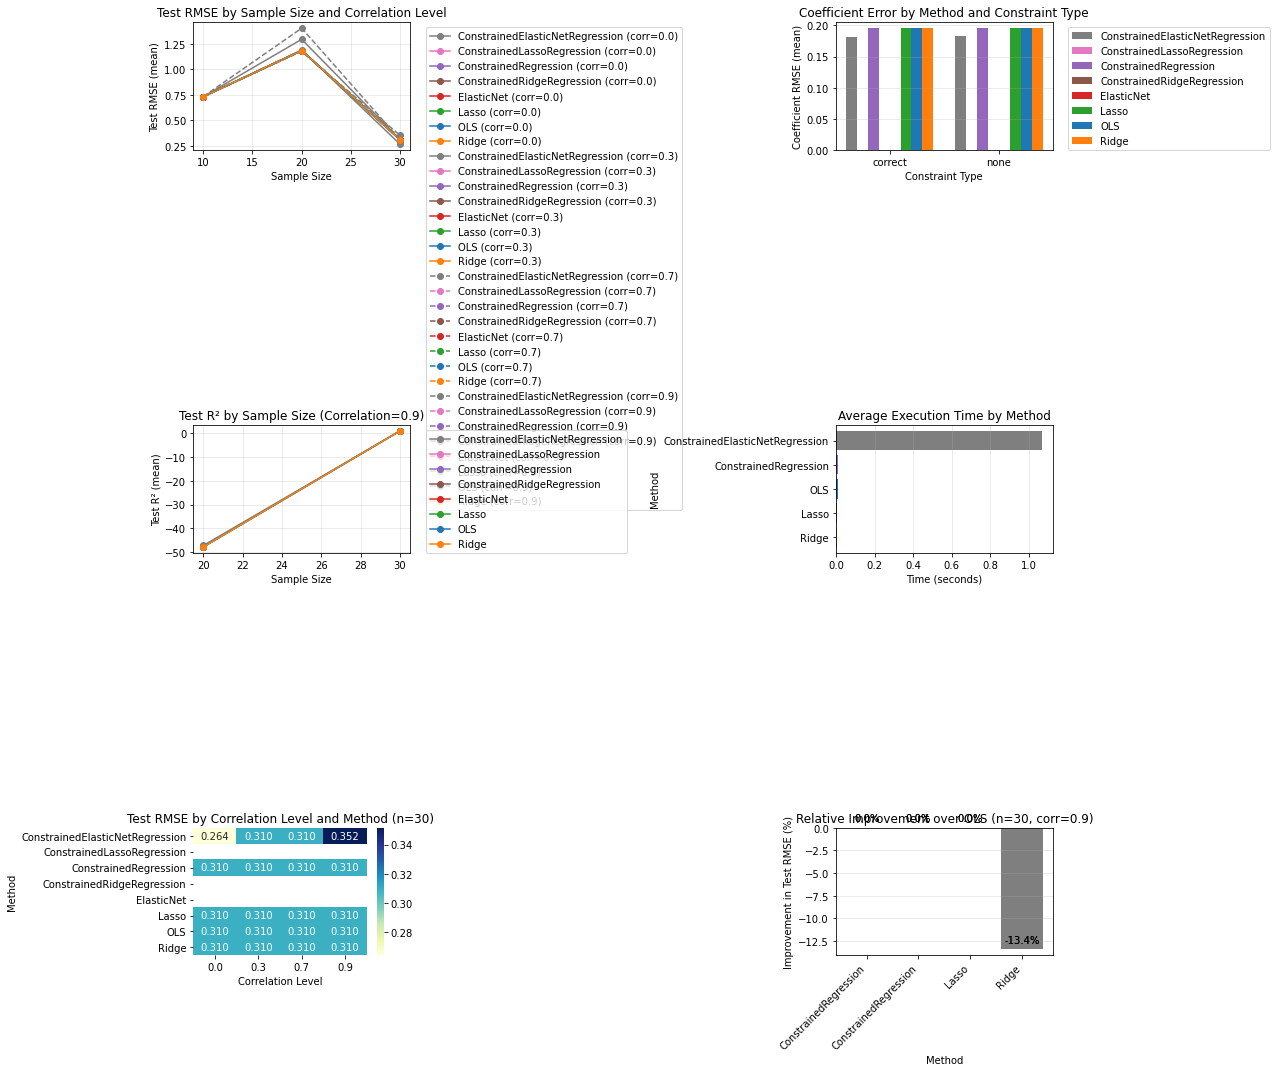

In [ ]:
# Plot results
print("Generating visualization...")
fig = plot_simulation_results(results_df)
fig.savefig(f"{rel_path}/monte_carlo_results.png", dpi=300, bbox_inches='tight')
print("Visualization saved to 'monte_carlo_results.png'")

In [ ]:
# Generate summary statistics
# Save summary statistics to a text file
f = open(f"{rel_path}/monte_carlo_summary.txt", "w")
print("\nSummary of Key Findings:")
# 1. Best method for small samples with high multicollinearity
small_high_corr = results_df[
    (results_df['n_samples'] == min(n_samples_list)) & 
    (results_df['corr_level'] == max(corr_levels)) &
    (results_df['constraints'] == 'correct')
].groupby('method')['test_rmse'].mean().sort_values()


print("\nPercentage of times the true coefs have the right sign")
def check_sign(coef, true_coef):
    '''Create a function to check if the coef as the same sign as the true coef
        coef: the coef to check (list of coefs)
        true_coef: the true coef (list of true coefs)
        return the percentage of times the coef has the same sign as the true coef
        '''
    result = 0
    for i in range(len(coef)):
        # handle nan values
        if coef[i]*true_coef[i] > 0:
            result += 1
    return result/len(coef)
def abs_diff_sum(coef, true_coef):
    '''Create a function to check if the coef as the same sign as the true coef
        coef: the coef to check (list of coefs)
        true_coef: the true coef (list of true coefs)
        return the percentage of times the coef has the same sign as the true coef
        '''
    result = 0
    for i in range(len(coef)):
        # handle nan values
        result=+np.abs(coef[i]-true_coef[i]) / np.abs(true_coef[i])

    return result


# check if the coef has the same sign as the true coef
results_df['sign_correct'] = results_df.apply(
    lambda row: check_sign(
        row[['coef_'+str(i) for i in range(n_features)]], 
        row[['true_coef_'+str(i) for i in range(n_features)]]), axis=1)

print(results_df.groupby('method')['sign_correct'].mean())
print(f"\nAbsolute error of the coefs and the true coefs")
results_df['true_coef_abs_error'] = results_df.apply(
    lambda row: np.sum(np.abs(row[['coef_'+str(i) for i in range(n_features)]] - row[['true_coef_'+str(i) for i in range(n_features)]])), axis=1)   
print(results_df.groupby(['method'])['true_coef_abs_error'].mean().reset_index().sort_values('true_coef_abs_error'))

print(f"\nBest methods for small samples (n={min(n_samples_list)}) with high multicollinearity (corr={max(corr_levels)}):")
for i, (method, rmse) in enumerate(small_high_corr.items()):
    if i < 3:  # Top 3
        print(f"  {i+1}. {method}: Test RMSE = {rmse:.4f}")

# 2. Average improvement of constrained methods over unconstrained
avg_results = results_df.groupby(['method', 'constraints']).agg({
    'test_rmse': 'mean',
    'coef_rmse': 'mean'
}).reset_index()

constrained_methods = [
    'ConstrainedRegression', 
    'ConstrainedRidgeRegression',
    'ConstrainedLassoRegression', 
    'ConstrainedElasticNetRegression'
]

unconstrained_methods = [
    'OLS', 
    'Ridge',
    'Lasso', 
    'ElasticNet'
]

# Calculate average for correct constraints
constrained_correct = avg_results[
    (avg_results['method'].isin(constrained_methods)) &
    (avg_results['constraints'] == 'correct')
]['test_rmse'].mean()

# Calculate average for unconstrained methods
unconstrained_avg = avg_results[
    avg_results['method'].isin(unconstrained_methods)
]['test_rmse'].mean()

improvement = (unconstrained_avg - constrained_correct) / unconstrained_avg * 100

print(f"\nAverage improvement of constrained methods with correct constraints: {improvement:.1f}%")

# 3. Impact of incorrect constraints
constrained_incorrect = avg_results[
    (avg_results['method'].isin(constrained_methods)) &
    (avg_results['constraints'] == 'incorrect')
]['test_rmse'].mean()

incorrect_impact = (constrained_incorrect - unconstrained_avg) / unconstrained_avg * 100

print(f"Impact of incorrect constraints: {incorrect_impact:.1f}% worse than unconstrained methods")

# 4. Best overall method
best_overall = results_df.groupby('method')['test_rmse'].mean().sort_values()

print("\nBest overall methods across all scenarios:")
for i, (method, rmse) in enumerate(best_overall.items()):
    if i < 3:  # Top 3
        f.write(f"  {i+1}. {method}: Average Test RMSE = {rmse:.4f}")
results_df.to_csv(f"{rel_path}/monte_carlo_results.csv", index=False)

print("Summary saved to 'monte_carlo_summary.txt'")
print(f)


Summary of Key Findings:

Percentage of times the true coefs have the right sign
method
ConstrainedElasticNetRegression    1.0
ConstrainedLassoRegression         0.0
ConstrainedRegression              1.0
ConstrainedRidgeRegression         0.0
ElasticNet                         0.0
Lasso                              1.0
OLS                                1.0
Ridge                              1.0
Name: sign_correct, dtype: float64

Absolute error of the coefs and the true coefs
                            method  true_coef_abs_error
0  ConstrainedElasticNetRegression                  0.0
1       ConstrainedLassoRegression                  0.0
2            ConstrainedRegression                  0.0
3       ConstrainedRidgeRegression                  0.0
4                       ElasticNet                  0.0
5                            Lasso                  0.0
6                              OLS                  0.0
7                            Ridge                  0.0

Best method